## 2. Segmentation

1. Plot avaiable data 
2. Otsus Threshold 
3. Multi-Otsu Threshold
4. Sauvola Threshold
5. Compare Methods
6. Apply Sauvola on 3D image


In [ ]:
# load packages 
from pathlib import Path
BASE_DIR = Path.cwd().parent
import stackview
from skimage import (exposure, feature, filters, io, measure,
                      morphology, restoration, segmentation, transform,
                      util) #good for all my deblurring approaches
import numpy as np
import matplotlib.pyplot as plt
import sys
sys.path.append(str(BASE_DIR / 'src'))
# python files
from skimage.filters import threshold_otsu
from skimage.segmentation import watershed
from scipy import ndimage as ndi
from skimage.feature import peak_local_max
from cellpose import models, io
from quantification import count_connexin_plaques_within_plaque, count_connexin_plaques
from threshold import savola_3D_image
from skimage.filters import threshold_multiotsu
from skimage.exposure import rescale_intensity
from skimage import img_as_float
from threshold import adapted_sauvola_threshold

In [37]:
# load small testing image 
preprocessed_image = io.imread(BASE_DIR / 'data/preprocessed/small_deconvolved_3d_planes150_160.tiff')
nuclei_mask = io.imread(BASE_DIR / 'data/raw/nuclei_dataset/nuclei_1_raw_Object Identities_test-exported_data_Input.tiff')
nuclei_mask = nuclei_mask[:,15:,:]

  0%|          | 0/10 [00:00<?, ?it/s]

100%|██████████| 441/441 [00:02<00:00, 194.11it/s]


## 1. Plot available Data

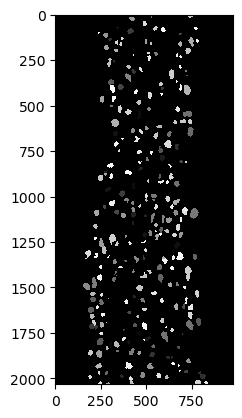

In [38]:
# segmented nuclei mask
stackview.imshow(nuclei_mask[155],axes = True)

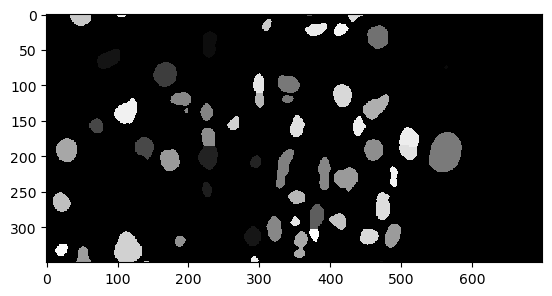

In [39]:
# closer image of nuclei mask
stackview.imshow(nuclei_mask[155, 900:1250,200:900],axes = True)

## 2. Otsus Threshold

In [12]:
threshold_value = threshold_otsu(preprocessed_image[0])
print("extracted threshold value:", threshold_value)

extracted threshold value: 1407


In [13]:
# Create a binary image using the threshold
binary_otsu = preprocessed_image[0] > threshold_value


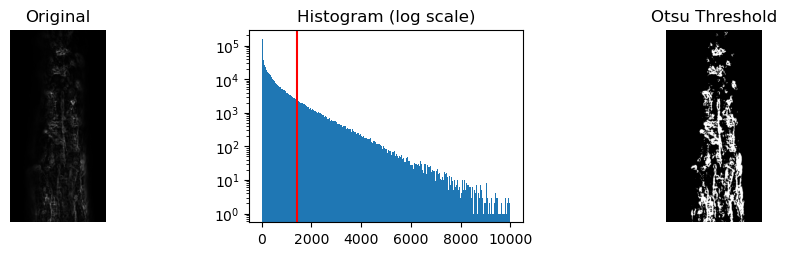

In [15]:
# new histogram with log scale 
fig, axes = plt.subplots(ncols=3, figsize=(12, 2.5))
ax = axes.ravel()
# Display the original image
ax[0].imshow(preprocessed_image[0], cmap=plt.cm.gray)
ax[0].set_title('Original')
ax[0].axis('off')
# Plot the histogram with the Otsu threshold marked in red
ax[1].hist(preprocessed_image[0].ravel(), bins=1000, range=(10, 10000), log=True)
ax[1].set_title('Histogram (log scale)')
ax[1].axvline(threshold_value, color='r')
# Display the thresholded image
ax[2].imshow(binary_otsu, cmap=plt.cm.gray)
ax[2].set_title('Otsu Threshold')
ax[2].axis('off')
# Show the subplots
plt.show()

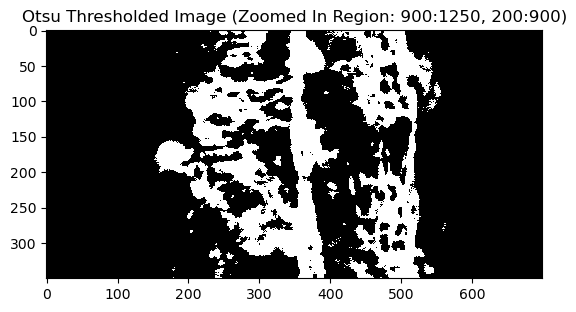

In [48]:
stackview.imshow(binary[900:1250,200:900], cmap=plt.cm.gray, title='Otsu Thresholded Image (Zoomed In Region: 900:1250, 200:900)', axes=True)

## 3. Multi-Otsu Threshold

In [17]:
# using bimodal histogram from scikit-image to find the threshold value
thresholds = threshold_multiotsu(preprocessed_image[0], classes=3)
print("extracted threshold values:", thresholds)

extracted threshold values: [ 812 2557]


In [18]:
binary_multiotsu = preprocessed_image[0] > thresholds[1]

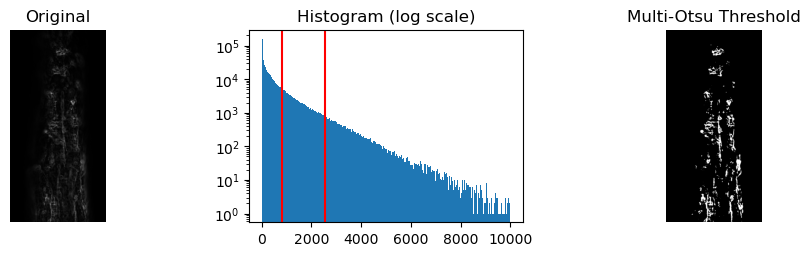

In [21]:
# new histogram with log scale 
fig, axes = plt.subplots(ncols=3, figsize=(12, 2.5))
ax = axes.ravel()
# Display the original image
ax[0].imshow(preprocessed_image[0], cmap=plt.cm.gray)
ax[0].set_title('Original')
ax[0].axis('off')
# Plot the histogram with the Otsu threshold marked in red
ax[1].hist(preprocessed_image[0].ravel(), bins=1000, range=(10, 10000), log=True)
ax[1].set_title('Histogram (log scale)')
ax[1].axvline(thresholds[0], color='r')
ax[1].axvline(thresholds[1], color='r')
# Display the thresholded image
ax[2].imshow(binary_multiotsu, cmap=plt.cm.gray)
ax[2].set_title('Multi-Otsu Threshold')
ax[2].axis('off')
# Show the subplots
plt.show()

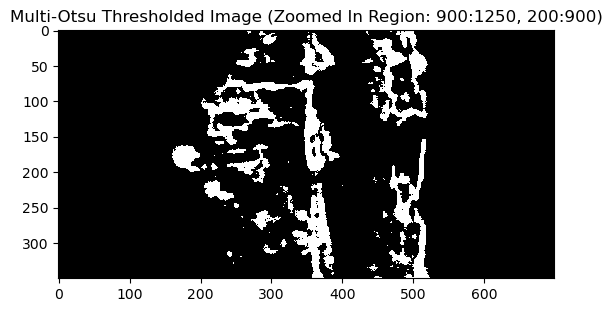

In [22]:
stackview.imshow(binary_multiotsu[900:1250,200:900], cmap=plt.cm.gray, title='Multi-Otsu Thresholded Image (Zoomed In Region: 900:1250, 200:900)', axes=True)

## 4. Sauvola Threshold

Number of connected components (plaques) detected: 9
Number of connected components (plaques) detected: 107
Number of connected components (plaques) detected: 171
Number of connected components (plaques) detected: 222
Plaques with min distance 2 detected: 9
Plaques with min distance 2 detected: 112
Plaques with min distance 2 detected: 183
Plaques with min distance 2 detected: 308


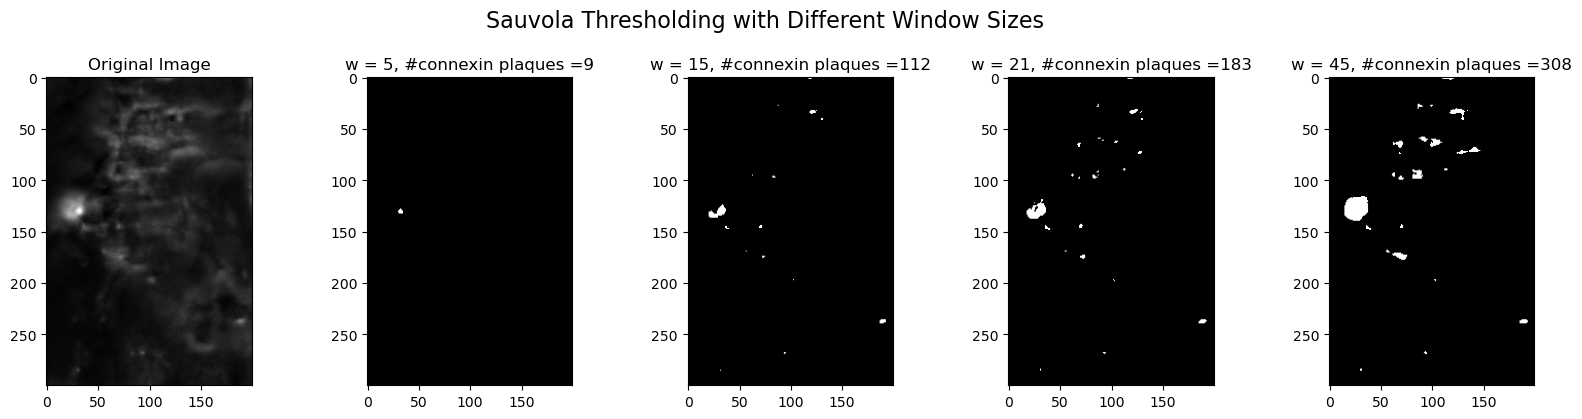

In [25]:
# set some parameters 
min_distance = 2 # connexin size / 2
k_value = 0.15


# Normalize preprocessed image to float [0, 1]
# k the bigger more selective and less foreground [0.2,0.5]
# window size should be 2-3 x diameter of connexin 
# r is 0.5 for image [0,1]
img_float = img_as_float(rescale_intensity(preprocessed_image[9], out_range=(0, 1)))

# Apply adapted Sauvola — no inversion needed
thresh, binary = adapted_sauvola_threshold(img_float, window_size=31, k = k_value , r=0.5)

# stackview.imshow(binary)

thresh, binary_5 = adapted_sauvola_threshold(img_float, window_size=5, k = k_value , r=0.5)
thresh, binary_15 = adapted_sauvola_threshold(img_float, window_size=15, k = k_value , r=0.5)
thresh, binary_21 = adapted_sauvola_threshold(img_float, window_size=21, k = k_value , r=0.5)
thresh, binary_45 = adapted_sauvola_threshold(img_float, window_size=45, k = k_value , r=0.5)

# compute the number of plaques for each binary image 
num_regions_5, labeled_array_5 = count_connexin_plaques(binary_5)
num_regions_15, labeled_array_15 = count_connexin_plaques(binary_15)
num_regions_21, labeled_array_21 = count_connexin_plaques(binary_21)
num_regions_45, labeled_array_45 = count_connexin_plaques(binary_45)

# compute the number of plaques for each binary image -> this counts 2 peaks that are closer than min_distance as one plaque
coordinates_5, n_plaques_5 = count_connexin_plaques_within_plaque(img_float, binary_5, min_distance=min_distance)
coordinates_15, n_plaques_15 = count_connexin_plaques_within_plaque(img_float, binary_15, min_distance=min_distance)
coordinates_25, n_plaques_25 = count_connexin_plaques_within_plaque(img_float, binary_21, min_distance=min_distance)
coordinates_45, n_plaques_45 = count_connexin_plaques_within_plaque(img_float, binary_45, min_distance=min_distance)

#make a subplot with different window sizes 
fig, axes = plt.subplots(1, 5, figsize=(20, 4))
# set a title for the entire figure with a distance from the top of the figure
fig.suptitle('Sauvola Thresholding with Different Window Sizes', fontsize=16, y=1.05)
axes[0].imshow(img_float[950:1250, 350:550], cmap='gray')
axes[0].set_title('Original Image')
axes[1].imshow(binary_5[950:1250, 350:550], cmap='gray')
axes[1].set_title(f'w = 5, #connexin plaques ={len(coordinates_5)}')
axes[2].imshow(binary_15[950:1250, 350:550], cmap='gray')
axes[2].set_title(f'w = 15, #connexin plaques ={len(coordinates_15)}')
axes[3].imshow(binary_21[950:1250, 350:550], cmap='gray')
axes[3].set_title(f'w = 21, #connexin plaques ={len(coordinates_25)}')
axes[4].imshow(binary_45[950:1250, 350:550], cmap='gray')
axes[4].set_title(f'w = 45, #connexin plaques ={len(coordinates_45)}')
plt.show()


# saving the best looking binary for final check
best_savola_binary_45 = binary_45

Local maxima detected : 10
Connected regions     : 12
Local maxima detected : 74
Connected regions     : 66
Local maxima detected : 82
Connected regions     : 63
Local maxima detected : 122
Connected regions     : 91


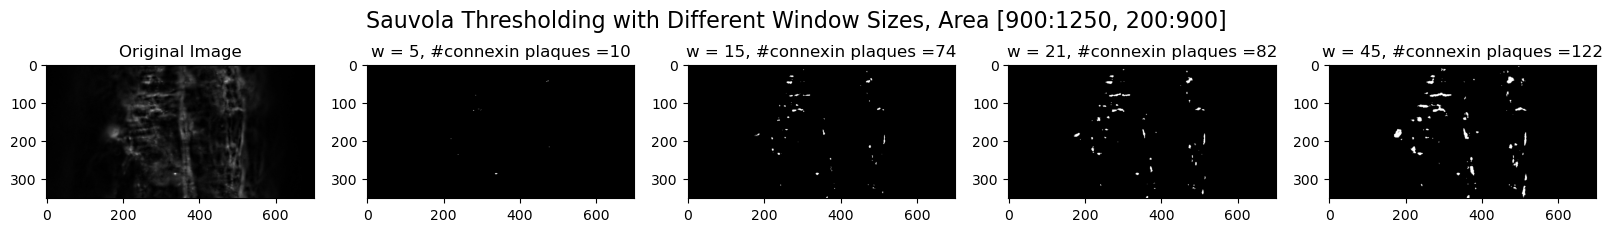

In [ ]:
from skimage.exposure import rescale_intensity
from skimage import img_as_float
from threshold import adapted_sauvola_threshold
from quantification import count_connexin_plaques

# Normalize your preprocessed image to float [0, 1]
# k the bigger more selective and less foreground [0.2,0.5]
# window size should be 2-3 x diameter of connexin 
# r is 0.5 for image [0,1]
img_float = img_as_float(rescale_intensity(preprocessed_image[0, 900:1250, 200:900], out_range=(0, 1)))

# Apply adapted Sauvola — no inversion needed
thresh, binary = adapted_sauvola_threshold(img_float, window_size=31, k=0.2, r=0.5)

# stackview.imshow(binary)

thresh, binary_5 = adapted_sauvola_threshold(img_float, window_size=5, k=0.2, r=0.5)
thresh, binary_15 = adapted_sauvola_threshold(img_float, window_size=15, k=0.2, r=0.5)
thresh, binary_21 = adapted_sauvola_threshold(img_float, window_size=21, k=0.2, r=0.5)
thresh, binary_45 = adapted_sauvola_threshold(img_float, window_size=45, k=0.2, r=0.5)

# compute the number of plaques for each binary image
coordinates_5, props_5, labeled_5 = count_connexin_plaques(img_float, binary_5, min_distance=min_distance)
coordinates_15, props_15, labeled_15 = count_connexin_plaques(img_float, binary_15, min_distance=min_distance)
coordinates_25, props_25, labeled_25 = count_connexin_plaques(img_float, binary_21, min_distance=min_distance)
coordinates_45, props_45, labeled_45 = count_connexin_plaques(img_float, binary_45, min_distance=min_distance)

#make a subplot with different window sizes 
fig, axes = plt.subplots(1, 5, figsize=(20, 4))
# set a title for the entire figure with a distance from the top of the figure
fig.suptitle('Sauvola Thresholding with Different Window Sizes, Area [900:1250, 200:900]', fontsize=16, y=0.8)
axes[0].imshow(img_float, cmap='gray')
axes[0].set_title('Original Image')
axes[1].imshow(binary_5, cmap='gray')
axes[1].set_title(f'w = 5, #connexin plaques ={len(coordinates_5)}')
axes[2].imshow(binary_15, cmap='gray')
axes[2].set_title(f'w = 15, #connexin plaques ={len(coordinates_15)}')
axes[3].imshow(binary_21, cmap='gray')
axes[3].set_title(f'w = 21, #connexin plaques ={len(coordinates_25)}')
axes[4].imshow(binary_45, cmap='gray')
axes[4].set_title(f'w = 45, #connexin plaques ={len(coordinates_45)}')
plt.show()


# saving the best looking binary for final check
best_savola_binary_45 = binary_45

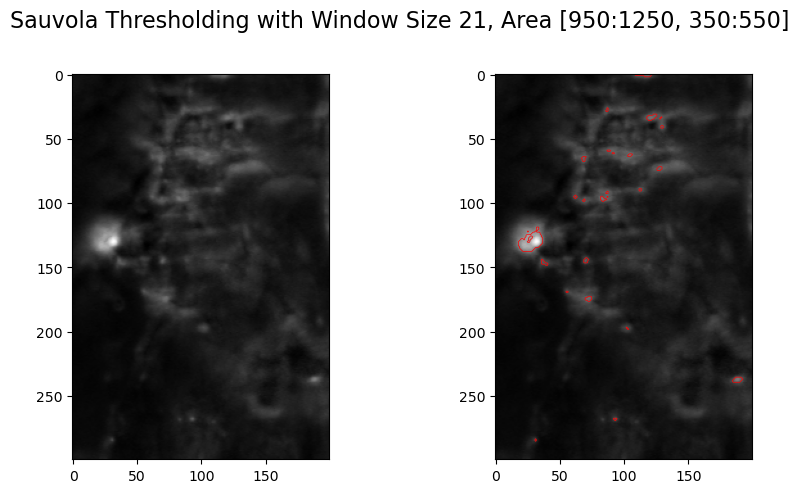

In [26]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(1,2, figsize=(10, 5))
fig.suptitle('Sauvola Thresholding with Window Size 21, Area [950:1250, 350:550]', fontsize=16, y=1.01)
ax[0].imshow(img_float[950:1250, 350:550], cmap='gray')
# ax.imshow(results['clean'][1200:1500,200:900], cmap='Reds', alpha=0.1, linewidth=2)
ax[1].imshow(img_float[950:1250, 350:550], cmap='gray')
ax[1].contour( binary_21[950:1250, 350:550], [0.5], linewidths=0.5, colors='r')
plt.show()

## 4. Compare Methods

In [29]:
mask_areas = io.imread(BASE_DIR / 'data/manual_annotations/small_deconvolved_3d_plane_160_labels.tif')

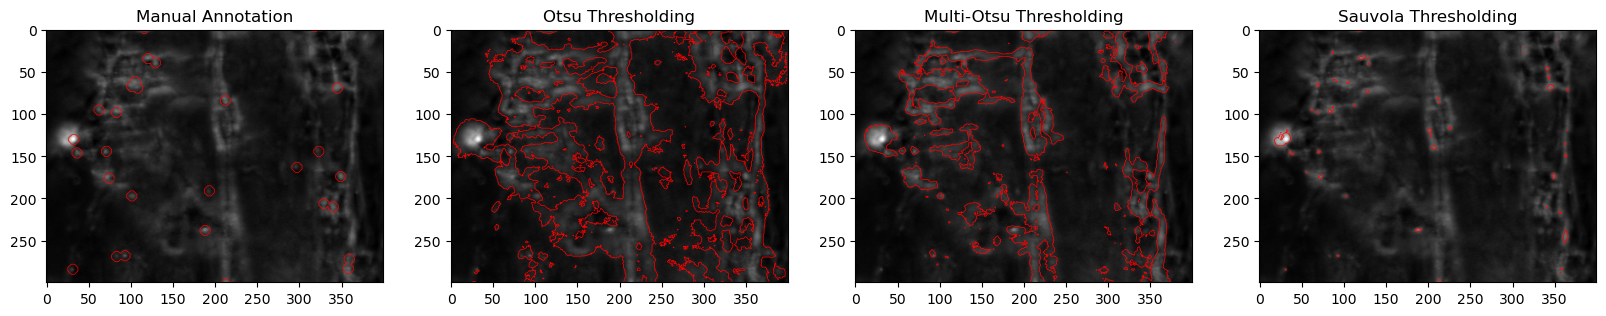

In [30]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(1,4, figsize=(20, 5))
# ax[0].imshow(img_float[950:1250, 350:550], cmap='gray')
# ax.imshow(results['clean'][1200:1500,200:900], cmap='Reds', alpha=0.1, linewidth=2)
ax[0].imshow(img_float[950:1250, 350:750], cmap='gray')
ax[0].contour(mask_areas[950:1250, 350:750], [0.5], linewidths=0.5, colors='r')
ax[0].set_title('Manual Annotation')
ax[1].imshow(img_float[950:1250, 350:750], cmap='gray')
ax[1].contour(binary_otsu[950:1250, 350:750], [0.5], linewidths=0.5, colors='r')
ax[1].set_title('Otsu Thresholding')
ax[2].imshow(img_float[950:1250, 350:750], cmap='gray')
ax[2].contour( binary_multiotsu[950:1250, 350:750], [0.5], linewidths=0.5, colors='r')
ax[2].set_title('Multi-Otsu Thresholding')
ax[3].imshow(img_float[950:1250, 350:750], cmap='gray')
ax[3].contour( binary_21[950:1250, 350:750], [0.5], linewidths=0.5, colors='r')
ax[3].set_title('Sauvola Thresholding')
plt.show()

## 5. Apply Sauvola on 3D image

In [31]:
import threshold

In [32]:
# apply the best sauvola thresholding to the entire image and visualize the results
binary_sauvola_img = threshold.savola_3D_image(preprocessed_image, window_size=(7, 21, 21), k=0.1, r=0.5, threeD = True) 

# save the binary_sauvola_img for later use
io.imsave(BASE_DIR / 'data/segmented/binary_sauvola3d_21_k0_1_img_10_slides.tiff', binary_sauvola_img)

In [34]:
count_connexin_plaques(binary_sauvola_img[0])

Number of connected components (plaques) detected: 328


(np.int32(328),
 array([[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]], shape=(2033, 1012), dtype=int32))

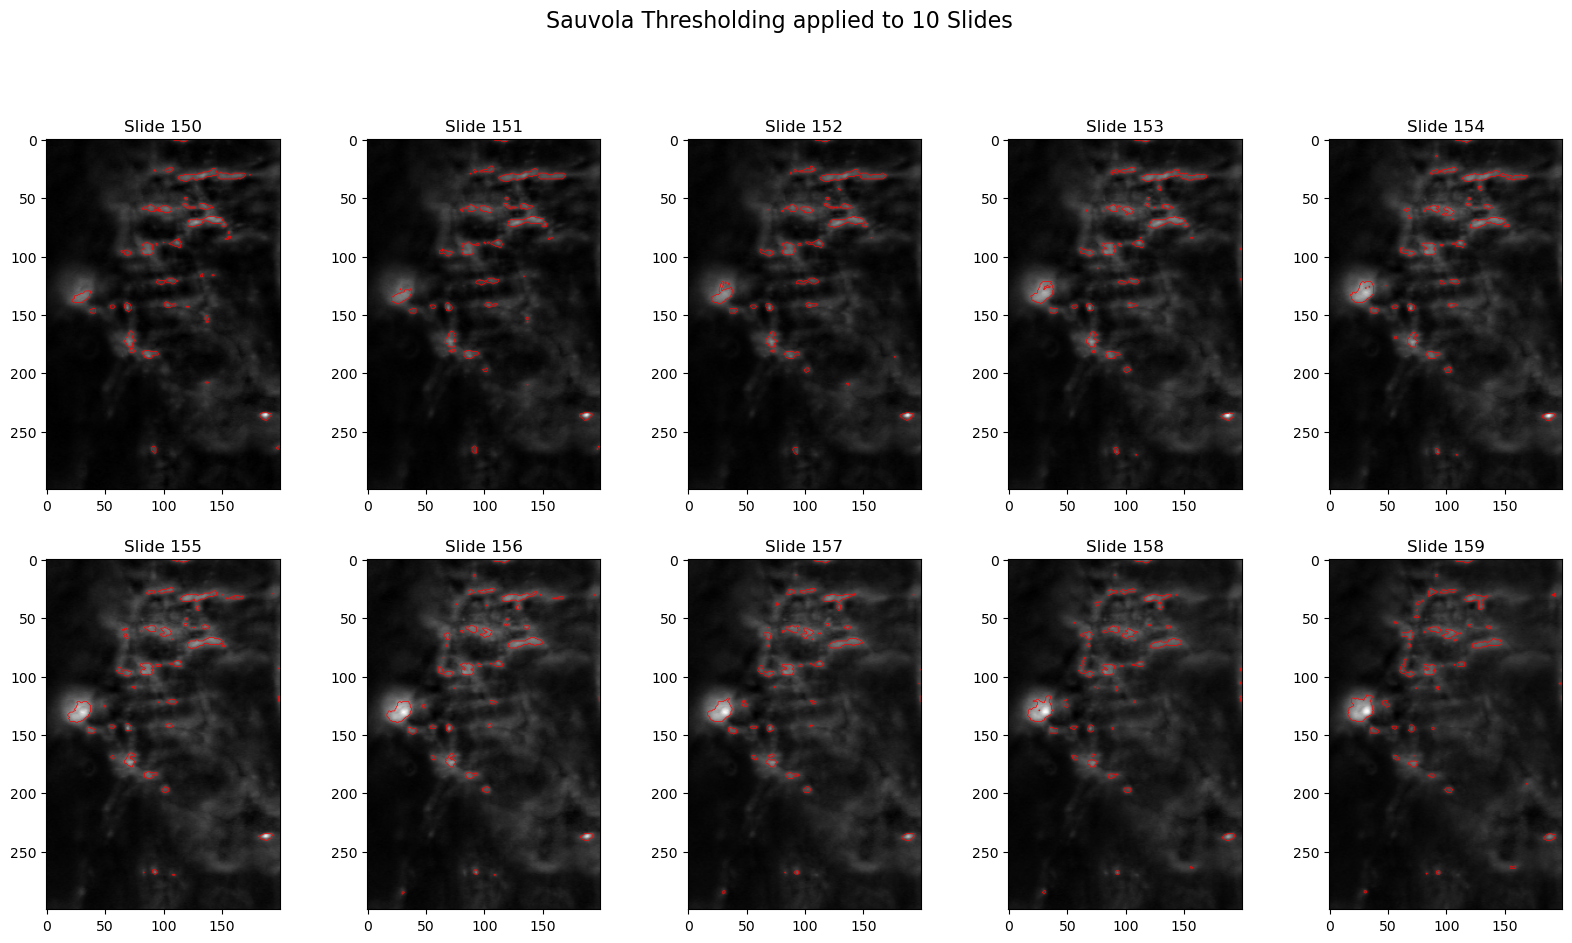

In [35]:
# plot 10 slides with segmented connexin next to each other
fig, ax = plt.subplots(2, 5, figsize=(20, 10))
fig.suptitle('Sauvola Thresholding applied to 10 Slides', fontsize=16, y=1.01)
for i in range(10):
    ax[i//5, i%5].imshow(preprocessed_image[i][950:1250, 350:550], cmap='gray')
    ax[i//5, i%5].contour(binary_sauvola_img[i][950:1250, 350:550], [0.5], linewidths=0.5, colors='r')
    ax[i//5, i%5].set_title(f'Slide {150+i}')

plt.show()